In [1]:

import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader

In [17]:
import sys
import os

# Go up one level to the project root (add more '..' if you are deeper)
project_root = os.path.abspath('..')
print(f"This is the project_root{project_root}")
if project_root not in sys.path:
    sys.path.append(project_root)
!git clone https://github.com/tom-esplin/midi-generator-model
%cd midi-generator-model

This is the project_root/content
Cloning into 'midi-generator-model'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 83 (delta 29), reused 75 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (83/83), 24.10 KiB | 24.10 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/midi-generator-model/midi-generator-model


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on {}".format(device))
print(torch.version.cuda)
print(torch.__version__)   

Running on cuda
12.8
2.10.0+cu128


In [3]:
%cd midi-generator-model/
genre = "folk"
from training.prep_dataset import MidiDataset, ContinuousMidiDataset
from pathlib import Path
from miditok import PerTok,TokSequence
#add function to autoselect genre path
#start with small dataset
CHUNK_SIZE = 1000
exp_path = Path("tokenization","saved_tokens","folk-0-04-04-2026_12-22-01")
tokenizer = PerTok(params=Path(exp_path,"tokenizer.json"))
print(f"Loaded Tokenizer Vocab Size: {len(tokenizer)}")

/content/midi-generator-model
Loaded Tokenizer Vocab Size: 30000


In [4]:
@torch.no_grad()
def generate(x, model, num_layers, hidden_dim, pred_length, temperature=0.8):
    # 1. Initialize hidden state
    hidden = torch.zeros(num_layers, x.size(0), hidden_dim).to(device)
    
    # 2. Warmup phase (x is a sequence, logits is 3D)
    logits, hidden = model(x, hidden)
    current_token = torch.multinomial(torch.softmax(logits[:, -1, :] / temperature, dim=-1), 1)
    
    generated_tokens = [x, current_token]

    # 3. Generation loop
    for _ in range(pred_length):
        logits, hidden = model(current_token, hidden)
        
        # FIX: Because of the wrapper, logits is now 2D: [batch, vocab_size]. 
        # We drop the [:, -1, :] indexing and just apply softmax directly!
        probs = torch.softmax(logits / temperature, dim=-1)
        
        # Sample the next token
        next_token = torch.multinomial(probs, 1) # shape: [batch, 1]
        
        generated_tokens.append(next_token)
        current_token = next_token # Use this for the next iteration
        
    # Concatenate all tokens along the sequence dimension (dim=1)
    return torch.cat(generated_tokens, dim=1)

In [5]:
eval_song = "001013_0.mid"
EVAL_START_TOKEN_IDS = torch.tensor(tokenizer(Path("prepared_data","folk","test",eval_song))[0].ids).unsqueeze(0)
EVAL_START_TOKEN_IDS = EVAL_START_TOKEN_IDS[:,:CHUNK_SIZE].to(device)
def evaluate(model,num_layers, hidden_dim, pred_length, iteration_count):
    """Runs generate function and formats and prints predictions.
    """
    model.eval()
    inference_batch = generate(EVAL_START_TOKEN_IDS, model, num_layers, hidden_dim, pred_length)
    for i,inference_tokens in enumerate(inference_batch):
        list_of_ids = inference_tokens.squeeze().tolist()
        tok_sequence = TokSequence(ids=list_of_ids,are_ids_encoded=True)
        pred_midi = tokenizer.decode([tok_sequence])
        pred_midi.dump_midi(Path(f"test_{iteration_count}.mid"))
    model.train()

In [6]:
VOCAB_SIZE = tokenizer.vocab_size

In [7]:
import time
from datetime import datetime
from tqdm import tqdm
import torch
import torch.nn as nn

def train_gru(model, num_layers, hidden_dim, optimizer, dataloader, n_optimization_steps, eval_interval):
    # Label smoothing adds a bit of uncertainty to the model, improving text generation.
    loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
    losses = []
    model.train()
    start_time = time.time()
    data_iter = iter(dataloader)
    
    for step in tqdm(range(n_optimization_steps)):
        try:
            batch = next(data_iter)
        except StopIteration as e:
            data_iter = iter(dataloader)
            batch = next(data_iter)

        batch = batch.to(device)
        hidden = torch.zeros(num_layers, batch.size(0), hidden_dim).to(device)
        
        x = batch[:, :-1].to(device) 
        # y_truth is the whole sequence except the first token
        y_truth = batch[:, 1:].to(device) 

        optimizer.zero_grad()
        hidden = torch.zeros(num_layers, batch.size(0), hidden_dim).to(device)

        # The model processes the ENTIRE sequence in a single forward pass
        y_hat, hidden = model(x, hidden) 

        # y_hat shape: (batch_size, seq_len, vocab_size)
        # Reshape for CrossEntropyLoss which expects (N, C)
        loss = loss_fn(y_hat.reshape(-1, VOCAB_SIZE), y_truth.flatten())

        loss.backward()
        optimizer.step()
        hidden = hidden.detach()
        losses.append(loss.item())
        
        # --- FIXED INDENTATION: Run eval and save AFTER the sequence loop finishes ---
        if (step + 1) % eval_interval == 0:
            model.eval()
            print(f"\nStep:{step} Loss {losses[-1]}\n\n")
            evaluate(model, num_layers, hidden_dim, CHUNK_SIZE, step)
            model.train()
            
        if time.time() - start_time >= 360000:
            timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            torch.save(model.state_dict(),'model_{}_{}'.format(timestamp, step))
            torch.save(optimizer.state_dict(),'optimizer_{}_{}'.format(timestamp, step))

    return losses

In [8]:



from models.gru import OptimizedGru
from torch.optim import Adam
print(exp_path)
dataset = MidiDataset(folder_path=Path(exp_path,"train"),chunk_size=CHUNK_SIZE)
print(len(dataset))
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
num_layers = 2
hidden_dim = 256
gru_model = OptimizedGru(tokenizer.vocab_size, embedding_dim=256, hidden_dim=hidden_dim, num_layers=num_layers).to(device)

optimizer = Adam(gru_model.parameters(), lr=5e-4)


tokenization/saved_tokens/folk-0-04-04-2026_12-22-01
5329


In [9]:
gru_losses = train_gru(gru_model, num_layers, hidden_dim, optimizer, dataloader, n_optimization_steps=2000, eval_interval=100)

  5%|▍         | 99/2000 [00:40<12:55,  2.45it/s]


Step:99 Loss 8.187232971191406




 10%|▉         | 199/2000 [01:22<12:26,  2.41it/s]


Step:199 Loss 8.177355766296387




 15%|█▍        | 299/2000 [02:04<11:49,  2.40it/s]

...

 95%|█████████▍| 1899/2000 [13:20<00:42,  2.39it/s]


Step:1899 Loss 6.467538356781006




100%|█████████▉| 1999/2000 [14:03<00:00,  2.38it/s]


Step:1999 Loss 6.413207054138184




100%|██████████| 2000/2000 [14:04<00:00,  2.37it/s]


In [ ]:
#save the model and optimizer state dicts
from google.colab import files
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
torch.save(gru_model.state_dict(),'models/saved_weights/gru_model_{}'.format(timestamp))
files.download('models/saved_weights/gru_model_{}'.format(timestamp))
torch.save(optimizer.state_dict(),'models/saved_weights/gru_optimizer_{}'.format(timestamp))
files.download('models/saved_weights/gru_optimizer_{}'.format(timestamp))

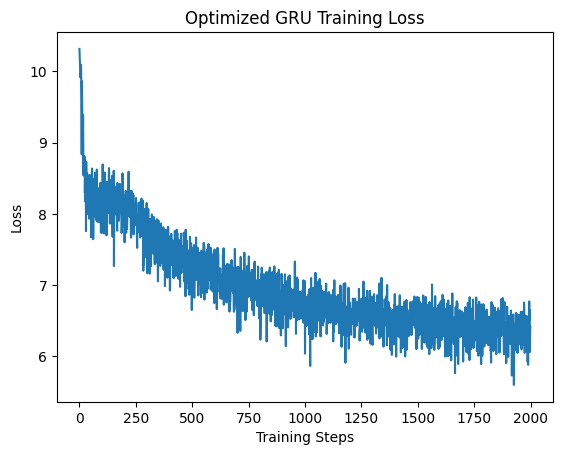

In [ ]:
plt.plot(gru_losses)
plt.title("Optimized GRU Training Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.savefig(f"opt_gru_training_loss_{timestamp}.png")
files.download(f'opt_gru_training_loss_{timestamp}.png')
plt.show()

In [31]:

from tqdm import tqdm
from torch.amp import autocast, GradScaler

def train_transformer(model, dataloader, optimizer, scheduler, device, epochs):
    # 1. Label smoothing is great for Transformers too!
    loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # 2. Initialize the GradScaler for Automatic Mixed Precision (AMP)
    scaler = GradScaler(device=device)
    
    model.to(device)
    model.train()
    total_training_steps = 0
    losses = []
    for epoch in range(epochs):
        epoch_loss = 0
        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for batch in progress_bar:
            batch = batch.to(device)
            
            # 3. Shift targets: x is the sequence, y_truth is the sequence shifted by 1
            x = batch[:, :-1] 
            y_truth = batch[:, 1:] 
            
            # 4. Generate the Causal Mask (prevents looking into the future)
            # Shape: (seq_len, seq_len). PyTorch native function.
            seq_len = x.size(1)
            causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(device)
            
            optimizer.zero_grad(set_to_none=True) # Slightly faster than standard zero_grad()
            
            # 5. Automatic Mixed Precision (AMP) Context
            # Runs the forward pass in fp16 (half precision) for massive speedups
            with autocast(str(device),dtype=torch.float16):
                # Process the ENTIRE sequence at once
                logits = model(x, mask=causal_mask)
                
                # Reshape for CrossEntropyLoss: (batch * seq_len, vocab_size)
                loss = loss_fn(logits.reshape(-1, logits.size(-1)), y_truth.flatten())
            losses.append(loss.item())
            # 6. Scaled Backward Pass
            scaler.scale(loss).backward()
            
            # 7. Gradient Clipping (CRITICAL for Transformers to prevent exploding gradients)
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            # 8. Optimizer and Scaler step
            scaler.step(optimizer)
            scaler.update()
            
            # 9. Step the Learning Rate Scheduler (Transformers usually need Warmup + Decay)
            if scheduler is not None:
                scheduler.step()
                
            epoch_loss += loss.item()
            progress_bar.set_postfix({"Loss": f"{loss.item():.4f}"})
            total_training_steps += 1

        print(f"Epoch {epoch+1} Average Loss: {epoch_loss / len(dataloader):.4f}")
    return losses,total_training_steps

In [32]:
from models.transformer import OptimizedTransformer
transformer_model = OptimizedTransformer(VOCAB_SIZE, d_model=256, nhead=8, max_seq_len=CHUNK_SIZE, num_layers=4).to(device)
# 3e-4 is the famous "Karpathy Constant" - a highly reliable starting learning rate
LEARNING_RATE = 3e-4  

optimizer = torch.optim.AdamW(
    transformer_model.parameters(), 
    lr=LEARNING_RATE, 
    weight_decay=0.01, # Helps prevent overfitting
    betas=(0.9, 0.95)  # Slightly tweaked from default (0.9, 0.999) for stability
)

EPOCHS = 10
# Assuming you already have your PyTorch DataLoader set up
total_training_steps = EPOCHS * len(dataloader)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    total_steps=total_training_steps,
    pct_start=0.1,      # Spend the first 10% of training warming up the LR
    anneal_strategy='cos' # Cosine decay for the remaining 90%
)

In [33]:
transformer_losses,total_training_steps = train_transformer(transformer_model, dataloader, optimizer, scheduler, device, epochs=EPOCHS)


Epoch 1/10: 100%|██████████| 167/167 [00:49<00:00,  3.39it/s, Loss=8.2889]


Epoch 1 Average Loss: 8.9696


Epoch 2/10: 100%|██████████| 167/167 [00:49<00:00,  3.40it/s, Loss=7.3224]


Epoch 2 Average Loss: 8.0253


Epoch 3/10: 100%|██████████| 167/167 [00:49<00:00,  3.39it/s, Loss=7.0626]


...

Epoch 8 Average Loss: 7.1635


Epoch 9/10: 100%|██████████| 167/167 [00:49<00:00,  3.39it/s, Loss=7.1405]


Epoch 9 Average Loss: 7.1424


Epoch 10/10: 100%|██████████| 167/167 [00:49<00:00,  3.39it/s, Loss=6.7577]

Epoch 10 Average Loss: 7.1347


In [ ]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
torch.save(transformer_model.state_dict(),'models/saved_weights/transformer_model_{}'.format(timestamp))
torch.save(optimizer.state_dict(),'models/saved_weights/transformer_optimizer_{}'.format(timestamp))
torch.save(scheduler.state_dict(),'models/saved_weights/transformer_scheduler_{}'.format(timestamp))
files.download('models/saved_weights/transformer_model_{}'.format(timestamp))
files.download('models/saved_weights/transformer_optimizer_{}'.format(timestamp))
files.download('models/saved_weights/transformer_scheduler_{}'.format(timestamp))

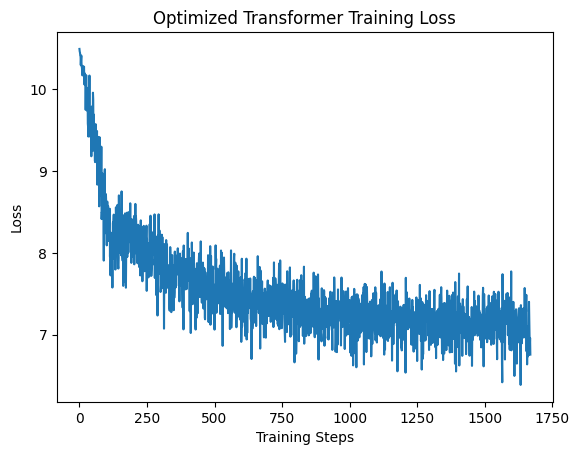

In [ ]:

plt.plot(transformer_losses)
plt.title("Optimized Transformer Training Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.savefig(f"opt_transformer_training_loss_{timestamp}.png")
files.download(f'opt_transformer_training_loss_{timestamp}.png')
plt.show()